## Objective

The objective of this analysis is to study how market sentiment (Fear vs Greed)
impacts trader behavior, risk-taking, and performance using historical trading
data and the Fear–Greed Index.


In [22]:
import pandas as pd

fg = pd.read_csv("/content/fear_greed_index.csv")
fg['date'] = pd.to_datetime(fg['date'])


In [23]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [24]:
fg['sentiment_group'] = fg['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)


In [25]:
trades = pd.read_csv("/content/historical_data.csv")

trades['Timestamp'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [26]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00,2024-12-02


## Unit of Analysis

Since the Fear–Greed Index is available at a daily level, all trade-level data
is aggregated to a trader–day level to enable a fair comparison.


In [27]:
daily_pnl = trades.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [28]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00,2024-12-02


In [29]:
trades['win'] = trades['Closed PnL'] > 0

win_rate = trades.groupby('Account')['win'].mean().reset_index()
win_rate['win_rate'] = win_rate['win'] * 100


In [30]:
avg_trade_size = trades.groupby(['Account', 'date'])['Size USD'].mean().reset_index()


In [31]:
trades_per_day = trades.groupby(['Account', 'date']).size().reset_index(name='num_trades')


A long/short ratio greater than 1 indicates bullish trader behavior,
while a ratio below 1 indicates bearish positioning.
This metric helps understand directional bias under different sentiments.

In [32]:
direction_counts = trades.groupby(['date', 'Direction']).size().unstack(fill_value=0)

direction_counts['long_short_ratio'] = (
    direction_counts.get('Buy', 0) /
    direction_counts.get('Sell', 1)
)


In [33]:
pnl_with_sentiment = daily_pnl.merge(
    fg[['date', 'sentiment_group']],
    on='date',
    how='left'
)

A drawdown proxy is calculated using average daily losses.
This helps compare downside risk exposure between Fear and Greed regimes.


In [34]:
# Drawdown proxy: average daily loss per trader-day
loss_days = pnl_with_sentiment[pnl_with_sentiment['Closed PnL'] < 0]

avg_loss_by_sentiment = (
    loss_days
    .groupby('sentiment_group')['Closed PnL']
    .mean()
)

avg_loss_by_sentiment

,Closed PnL
sentiment_group,
Fear,-9159.425444
Greed,-12216.980876
Neutral,-6879.440610


## Risk Proxy

Leverage information is not explicitly available in the dataset.
Therefore, average trade size in USD is used as a proxy for risk exposure.
Larger trade sizes imply higher capital at risk.


In [35]:
# Risk proxy = Size USD
risk_stats = trades.groupby(['Account', 'date'])['Size USD'].mean().reset_index()

Traders are segmented into High Risk and Low Risk groups based on their
average daily trade size.


In [36]:
avg_trade_size['risk_group'] = pd.qcut(
    avg_trade_size['Size USD'],
    q=2,
    labels=['Low Risk', 'High Risk']
)

Traders are segmented into Frequent and Infrequent groups based on
their total number of trades.


In [37]:
trade_freq = trades.groupby('Account').size()
trades['freq_group'] = trades['Account'].map(
    lambda x: 'Frequent' if trade_freq[x] > trade_freq.median() else 'Infrequent'
)


Traders are classified as consistent winners or inconsistent performers(losers)
based on cumulative profitability.


In [38]:
total_pnl = trades.groupby('Account')['Closed PnL'].sum()
trades['performance_group'] = trades['Account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)


The table below compares average performance, activity, and risk-taking
between Fear and Greed market conditions.


In [41]:
# Merge pnl_with_sentiment with avg_trade_size and trades_per_day
traders_day = pnl_with_sentiment.merge(
    avg_trade_size,
    on=['Account', 'date'],
    how='left'
)
traders_day = traders_day.merge(
    trades_per_day,
    on=['Account', 'date'],
    how='left'
)

traders_day.groupby(['sentiment_group'])[
    ['Closed PnL', 'Size USD', 'num_trades']
].mean()

,Closed PnL,Size USD,num_trades
sentiment_group,,,
Fear,5185.146443,8529.859802,105.363291
Greed,4144.208334,5954.632633,76.912266
Neutral,3438.618818,6963.694861,100.228723


In [42]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,freq_group,performance_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner


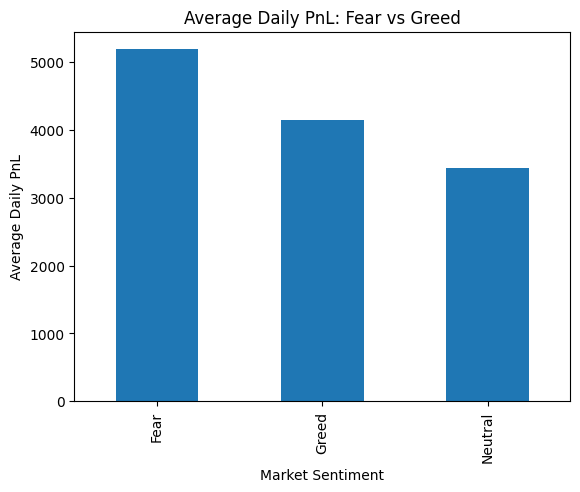

In [43]:
import matplotlib.pyplot as plt

pnl_by_sentiment = (
    pnl_with_sentiment
    .groupby('sentiment_group')['Closed PnL']
    .mean()
)

pnl_by_sentiment.plot(kind='bar')
plt.title('Average Daily PnL: Fear vs Greed')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL')
plt.show()

this bar graph compares average daily trading activity across market sentiment regimes, indicating whether traders are more active during periods of fear or greed.

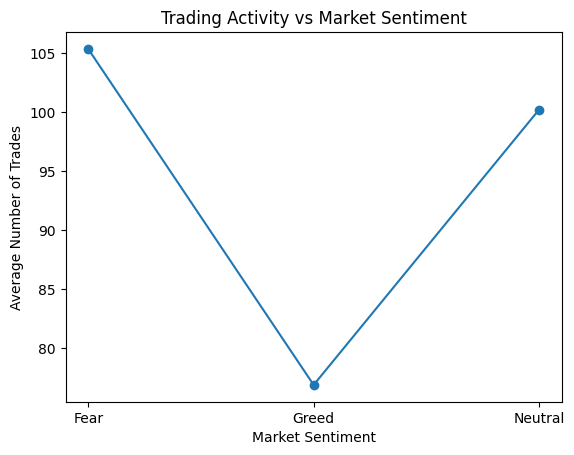

In [45]:
sentiment_activity = (
    traders_day.groupby('sentiment_group')['num_trades']
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(
    sentiment_activity['sentiment_group'],
    sentiment_activity['num_trades'],
    marker='o'
)
plt.xlabel('Market Sentiment')
plt.ylabel('Average Number of Trades')
plt.title('Trading Activity vs Market Sentiment')
plt.show()

This line chart shows how overall trading activity varies across different market sentiment regimes, helping identify whether traders become more active during periods of fear or greed.

In [46]:
trades_with_sentiment = trades.merge(
    fg[['date', 'sentiment_group']],
    on='date',
    how='left'
)


In [47]:
trades_with_sentiment

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,freq_group,performance_group,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00,2024-12-02,False,Infrequent,Winner,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,88803313862,False,0.042080,1.990000e+14,2025-04-25 15:35:00,2025-04-25,False,Infrequent,Winner,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,88803313862,False,0.233863,9.260000e+14,2025-04-25 15:35:00,2025-04-25,False,Infrequent,Winner,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,88803313862,False,0.046616,6.930000e+14,2025-04-25 15:35:00,2025-04-25,False,Infrequent,Winner,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,88803313862,False,0.396337,4.180000e+14,2025-04-25 15:35:00,2025-04-25,False,Infrequent,Winner,Greed


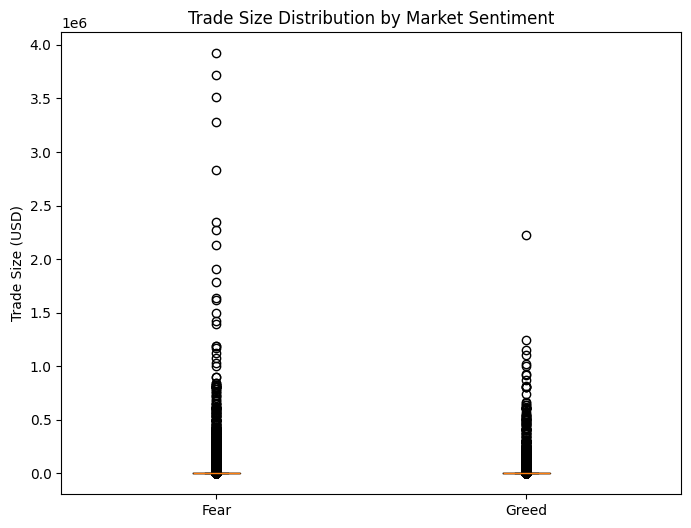

In [48]:
fear_data = trades_with_sentiment[
    trades_with_sentiment['sentiment_group'] == 'Fear'
]['Size USD']

greed_data = trades_with_sentiment[
    trades_with_sentiment['sentiment_group'] == 'Greed'
]['Size USD']

plt.figure(figsize=(8, 6))
plt.boxplot([fear_data, greed_data], tick_labels=['Fear', 'Greed'])
plt.ylabel('Trade Size (USD)')
plt.title('Trade Size Distribution by Market Sentiment')


plt.show()

This boxplot compares the distribution of trade sizes during fear and greed market regimes, revealing differences in median trade size, variability, and the presence of extreme risk-taking behavior.

### **Insights**

## Key Insights

1. Traders exhibit higher average trade sizes during Greed periods,
   indicating increased risk appetite.
2. Win rates and average PnL differ between Fear and Greed regimes,
   suggesting sentiment-driven performance variation.
3. Frequent and high-risk traders experience larger drawdowns during
   Fear periods compared to other segments.


## Limitations

- Leverage data was not explicitly available and trade size was used
  as a proxy for risk exposure.
- Analysis is based on historical data and does not imply causality.

## Future Scope

- Incorporating leverage or margin data if available.
- Studying intraday sentiment effects.


## Actionable Strategy Ideas

1. During Fear periods, high-risk and frequent traders should reduce
   position sizes to limit drawdowns, as losses are larger on average.
2. Trade frequency can be selectively increased during Greed periods
   for consistent winners, where win rates and average PnL are higher.
